In [2]:
# ====================
# OS setting
# ====================
import os, logging
path = os.path.expanduser("./") # for local runs
folder_name = "noi"
do_rm = False 
do_skip = False
out_csv = "./network_dvv.csv"

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime, timezone
from datetimerange import DateTimeRange

from obspy.signal.filter import bandpass
from noisepy.seis import noise_module, cross_correlate

from noisepy.seis.io.asdfstore import ASDFCCStore
from noisepy.seis.io.datatypes import ConfigParameters, StackMethod, CCMethod, FreqNorm, RmResp, TimeNorm 
from noisepy.seis.io.channel_filter_store import channel_filter
from noisepy.seis.io.channelcatalog import XMLStationChannelCatalog        # Required stationXML handling object
from noisepy.seis.io.s3store import SCEDCS3DataStore    # Object to query SCEDC data from on S3
from noisepy.seis.io.plotting_modules import plot_substack_cc

from noisepy.monitoring.monitoring_utils import *     # modules for monitoring utils
from noisepy.monitoring.monitoring_methods import stretching
from noisepy.monitoring.attenuation_utils import *    # modules for attenuation monitoring

logger = logging.getLogger(__name__)

os.makedirs(path,exist_ok=True)
start_date = datetime(2019, 1, 1, tzinfo=timezone.utc)
end_date = datetime(2019, 1, 2, tzinfo=timezone.utc)
print(start_date, end_date)



config = ConfigParameters()

config.start_date = start_date
config.end_date = end_date

config.inc_hours = 24
config.sampling_rate = 20
config.cc_len = 1800
config.step = 1800
config.substack = True

config.ncomp = 3
config.acorr_only = False
config.xcorr_only = True

config.lamin = 31
config.lamax = 42
config.lomin = -124
config.lomax = -115
config.networks = ["CI"]
config.stations = ["LJR", "DLA", "LAF","STS", "RINB"]
'''
config.stations = [
    "LSS","KML","SDD","CWP","RKMP",
     "STG","ELS","LMH","LMS","PLS",
     "SRN","FMP","RPV","STS","DLA",
     "BRE","CHL","MLS","CHN","SSS",
     "RVR","RSB","CLT","IPT","SS2",
     "CJM","LPC","BFS","SUN","PDU",
     "PSR","RIO","WLT","OLI","TCC",
     "RUS","PEM","XTL","CFL","MWC",
     "GOU","JPLS","WTT","LGB","USC",
     "LTP","LAF","PDR","LCG","BHP",
     "SMF","SPF","WSS","BLC","OAT",
     "LFP","RINB","HLL","DEC"
]
'''
config.channels = ["BH?", "HH?"]

config.stationxml = False
config.rm_resp = RmResp.INV

config.freqmin = 0.008
config.freqmax = 7.0
config.max_over_std = 10

config.freq_norm = FreqNorm.RMA
config.smoothspect_N = 10   
config.time_norm = TimeNorm.ONE_BIT
config.smooth_N = 10

config.cc_method = CCMethod.XCORR
config.stack_method = StackMethod.LINEAR   


config.substack_windows = 1   # keep the finest time resolution first
config.maxlag = 60            # or larger if your coda analysis needs it

2019-02-01 00:00:00+00:00 2020-01-01 00:00:00+00:00


In [ ]:
# S3 paths for raw data and stationXML
S3_STORAGE_OPTIONS = {"s3": {"anon": True}} # S3 storage options
S3_DATA = "s3://scedc-pds/continuous_waveforms/" # Continuous waveform data
S3_STATION_XML = "s3://scedc-pds/FDSNstationXML/CI/"    # StationXML files for CI network
# S3 data store
timerange = DateTimeRange(config.start_date, config.end_date)
catalog = XMLStationChannelCatalog(S3_STATION_XML, storage_options=S3_STORAGE_OPTIONS) # Station catalog
raw_store = SCEDCS3DataStore(S3_DATA, catalog, 
                             channel_filter(config.networks, config.stations, config.channels),
                             timerange, storage_options=S3_STORAGE_OPTIONS) # Store for reading raw data from S3 bucket
# CC store 
cc_data_path = os.path.join(path, folder_name)
cc_store = ASDFCCStore(cc_data_path)

# For this tutorial make sure the previous run is empty

if (do_rm):
    os.system(f"rm -rf {cc_data_path}")
if (not do_skip):
# Cross-correlation
    cross_correlate(raw_store, config, cc_store)

# Save config parameters
xcorr_config_fn = 'xcorr_config.yml'
config.save_yaml(xcorr_config_fn)

In [20]:
import numpy as np
from datetime import datetime, timezone, timedelta

from noisepy.seis.io.asdfstore import ASDFCCStore


def read_component_substacks(cc_data_path, src, rec, comp="ZZ", min_ngood=1):
    """
    Read all saved substacks for one station pair/component from a NoisePy ASDFCCStore.

    Returns
    -------
    traces : (N, npts) float array
    times  : (N,) float array of UTC timestamps (seconds since epoch)
    dt     : float
    maxlag : float
    """
    cc_store = ASDFCCStore(cc_data_path, mode="r")
    timespans = cc_store.get_timespans(src, rec)

    traces = []
    times = []
    dt = None
    maxlag = None

    for ts in timespans:
        ch_pairs = cc_store.read(ts, src, rec)

        for ch_pair in ch_pairs:
            params = ch_pair.parameters
            all_data = np.asarray(ch_pair.data)
            this_comp = str(params["comp"]).upper()

            if this_comp != comp.upper():
                continue

            tgood = np.atleast_1d(np.asarray(params["ngood"]))
            ttime = np.atleast_1d(np.asarray(params["time"], dtype=float))
            this_dt = float(params["dt"])
            this_maxlag = float(params["maxlag"])

            if dt is None:
                dt = this_dt
                maxlag = this_maxlag
            else:
                if abs(this_dt - dt) > 1e-8 or abs(this_maxlag - maxlag) > 1e-6:
                    raise ValueError("Inconsistent dt or maxlag across substacks.")

            # If substack=True, data is usually 2D: (n_substacks, npts)
            # If a chunk only contains one trace, make it 2D for uniform handling.
            if all_data.ndim == 1:
                all_data = all_data[None, :]

            for i in range(all_data.shape[0]):
                ng = tgood[min(i, len(tgood) - 1)]
                if ng < min_ngood:
                    continue
                traces.append(all_data[i].astype(np.float32))
                times.append(ttime[min(i, len(ttime) - 1)])

    if not traces:
        raise ValueError(f"No traces found for {src}-{rec} component {comp}")

    traces = np.vstack(traces)
    times = np.asarray(times, dtype=float)

    # sort by time
    order = np.argsort(times)
    traces = traces[order]
    times = times[order]

    return traces, times, dt, maxlag


def rolling_stack_by_time(traces, times, stack_length_days=21, step_days=1, min_count=1):
    """
    Build rolling linear stacks using actual timestamps.

    Parameters
    ----------
    traces : (N, npts)
    times  : (N,) epoch seconds
    stack_length_days : float
    step_days : float
    min_count : int
        Minimum number of substacks required to emit a rolling stack.

    Returns
    -------
    stack_times : list of datetime
        Timestamp assigned to each rolling stack (center of window).
    stacks : (M, npts) array
    counts : (M,) array
        Number of substacks used in each rolling stack.
    """
    stack_len_sec = stack_length_days * 86400.0
    step_sec = step_days * 86400.0

    t0 = times.min()
    t1 = times.max()

    start = t0
    stack_times = []
    stacks = []
    counts = []

    while start + stack_len_sec <= t1 + 1e-6:
        end = start + stack_len_sec
        idx = np.where((times >= start) & (times < end))[0]

        if len(idx) >= min_count:
            stacks.append(np.mean(traces[idx], axis=0))
            counts.append(len(idx))
            center = start + 0.5 * stack_len_sec
            stack_times.append(datetime.fromtimestamp(center, tz=timezone.utc))

        start += step_sec

    if len(stacks) == 0:
        return [], np.empty((0, traces.shape[1]), dtype=np.float32), np.array([], dtype=int)

    return stack_times, np.vstack(stacks), np.asarray(counts, dtype=int)
#--------------------------------------------------------------------------



In [21]:
import numpy as np
from obspy.signal.filter import bandpass
import time

def _weighted_line_fit(x, y, w=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    if w is None:
        w = np.ones_like(x)
    else:
        w = np.asarray(w, dtype=float)
        mask &= np.isfinite(w) & (w > 0)

    x = x[mask]
    y = y[mask]
    w = w[mask]

    if len(x) < 2:
        return np.nan, np.nan, np.nan

    X = np.column_stack([x, np.ones_like(x)])
    W = w[:, None]

    XtWX = X.T @ (W * X)
    XtWy = X.T @ (w * y)

    try:
        beta = np.linalg.solve(XtWX, XtWy)
    except np.linalg.LinAlgError:
        return np.nan, np.nan, np.nan

    slope, intercept = beta
    resid = y - (slope * x + intercept)

    dof = max(len(x) - 2, 1)
    sigma2 = np.sum(w * resid**2) / dof

    try:
        cov = sigma2 * np.linalg.inv(XtWX)
        slope_err = np.sqrt(cov[0, 0])
    except np.linalg.LinAlgError:
        slope_err = np.nan

    return slope, intercept, slope_err


def _mwcs_delay_one_window(ref_win, cur_win, dt, freq_band, min_freq_points=5):
    ref_win = np.asarray(ref_win, dtype=float)
    cur_win = np.asarray(cur_win, dtype=float)

    if len(ref_win) != len(cur_win) or len(ref_win) < 8:
        return np.nan, np.nan, np.nan

    # demean + taper
    taper = np.hanning(len(ref_win))
    rw = (ref_win - np.mean(ref_win)) * taper
    cw = (cur_win - np.mean(cur_win)) * taper

    # FFT
    R = np.fft.rfft(rw)
    C = np.fft.rfft(cw)
    freqs = np.fft.rfftfreq(len(rw), d=dt)

    # cross spectrum
    X = C * np.conj(R)
    phase = np.unwrap(np.angle(X))
    amp = np.abs(X)

    fmin, fmax = freq_band
    mask = (freqs >= fmin) & (freqs <= fmax) & np.isfinite(phase) & (amp > 0)

    if np.sum(mask) < min_freq_points:
        return np.nan, np.nan, np.nan

    omega = 2.0 * np.pi * freqs[mask]
    phi = phase[mask]
    weights = amp[mask]

    # phase ~= -omega * delay + const
    slope, intercept, slope_err = _weighted_line_fit(omega, phi, weights)

    if not np.isfinite(slope):
        return np.nan, np.nan, np.nan

    delay = -slope
    delay_err = slope_err

    # simple QC metric
    cc = np.corrcoef(rw, cw)[0, 1] if np.std(rw) > 0 and np.std(cw) > 0 else np.nan

    return delay, delay_err, cc


def _extract_window(trace, t_axis, t0, t1):
    idx = np.where((t_axis >= t0) & (t_axis < t1))[0]
    return idx, trace[idx]


def _mwcs_side_dvv(
    ref_trace,
    cur_trace,
    t_axis,
    coda,
    moving_window_length,
    moving_window_step,
    dt,
    freq_band,
    side="positive",
):
    coda_start, coda_end = coda
    win_len = moving_window_length
    win_step = moving_window_step

    starts = np.arange(coda_start, coda_end - win_len + 1e-12, win_step)

    centers = []
    delays = []
    delay_errs = []
    ccs = []

    for s in starts:
        e = s + win_len

        if side == "positive":
            idx_ref, ref_win = _extract_window(ref_trace, t_axis, s, e)
            idx_cur, cur_win = _extract_window(cur_trace, t_axis, s, e)
        elif side == "negative":
            idx_ref, ref_win = _extract_window(ref_trace, t_axis, -e, -s)
            idx_cur, cur_win = _extract_window(cur_trace, t_axis, -e, -s)
        else:
            raise ValueError("side must be 'positive' or 'negative'")

        if len(ref_win) != len(cur_win) or len(ref_win) < 8:
            continue

        delay, delay_err, cc = _mwcs_delay_one_window(
            ref_win, cur_win, dt, freq_band
        )

        if np.isfinite(delay):
            centers.append(0.5 * (s + e))   # use positive lapse time on both sides
            delays.append(delay)
            delay_errs.append(delay_err)
            ccs.append(cc)

    centers = np.asarray(centers, dtype=float)
    delays = np.asarray(delays, dtype=float)
    delay_errs = np.asarray(delay_errs, dtype=float)
    ccs = np.asarray(ccs, dtype=float)

    if len(centers) < 3:
        return {
            "centers": centers,
            "delays": delays,
            "delay_errs": delay_errs,
            "ccs": ccs,
            "dvv": np.nan,
            "dvv_err": np.nan,
        }

    # delay(t) ≈ - (dv/v) * t
    # slope of delay vs lapse time = -dv/v
    weights = np.ones_like(delay_errs)
    finite_err = np.isfinite(delay_errs) & (delay_errs > 0)
    if np.any(finite_err):
        weights[finite_err] = 1.0 / (delay_errs[finite_err] ** 2)

    slope, intercept, slope_err = _weighted_line_fit(centers, delays, weights)

    dvv = -100.0 * slope
    dvv_err = 100.0 * slope_err if np.isfinite(slope_err) else np.nan

    return {
        "centers": centers,
        "delays": delays,
        "delay_errs": delay_errs,
        "ccs": ccs,
        "dvv": dvv,
        "dvv_err": dvv_err,
    }


def compute_dvv_from_rolling_stacks(
    stacks,
    stack_times,
    dt,
    maxlag,
    freq=(1.5, 6.0),
    coda=(15.0, 40.0),
    moving_window_length=1.75,
    moving_window_step=0.25,   # paper table usually gives length, not always step
    reference="mean",          # "mean" or integer index
):
    """
    MWCS-style dv/v from rolling-stacked correlation functions.

    Parameters
    ----------
    stacks : array, shape (N, npts)
        Rolling stacks in time.
    stack_times : list
        Times corresponding to each rolling stack.
    dt : float
        Sampling interval in seconds.
    maxlag : float
        Max lag in seconds.
    freq : tuple
        Bandpass / MWCS frequency band, e.g. (1.5, 6.0).
    coda : tuple
        Coda lag-time window, e.g. (15.0, 40.0).
    moving_window_length : float
        MWCS small-window length in seconds, e.g. 1.75.
    moving_window_step : float
        Step between MWCS small windows in seconds.
    reference : "mean" or int
        Reference stack choice.

    Returns
    -------
    result : dict
    """
    stacks = np.asarray(stacks, dtype=float)
    nstack, npts = stacks.shape
    fs = int(round(1.0 / dt))

    # lag axis
    t_axis = np.linspace(-maxlag, maxlag, npts)

    # bandpass all stacks
    filtered = np.zeros_like(stacks)
    for i in range(nstack):
        filtered[i] = bandpass(
            stacks[i],
            freq[0],
            freq[1],
            fs,
            corners=4,
            zerophase=True,
        )

    # choose reference
    if reference == "mean":
        ref_trace = np.mean(filtered, axis=0)
    elif isinstance(reference, int):
        ref_trace = filtered[reference].copy()
    else:
        raise ValueError("reference must be 'mean' or an integer index")

    dvv_pos = np.full(nstack, np.nan)
    dvv_neg = np.full(nstack, np.nan)
    err_pos = np.full(nstack, np.nan)
    err_neg = np.full(nstack, np.nan)
    cc_pos = np.full(nstack, np.nan)
    cc_neg = np.full(nstack, np.nan)

    pos_details = []
    neg_details = []

    for i in range(nstack):
        cur_trace = filtered[i]

        pos = _mwcs_side_dvv(
            ref_trace, cur_trace, t_axis,
            coda=coda,
            moving_window_length=moving_window_length,
            moving_window_step=moving_window_step,
            dt=dt,
            freq_band=freq,
            side="positive",
        )

        neg = _mwcs_side_dvv(
            ref_trace, cur_trace, t_axis,
            coda=coda,
            moving_window_length=moving_window_length,
            moving_window_step=moving_window_step,
            dt=dt,
            freq_band=freq,
            side="negative",
        )

        dvv_pos[i] = pos["dvv"]
        dvv_neg[i] = neg["dvv"]
        err_pos[i] = pos["dvv_err"]
        err_neg[i] = neg["dvv_err"]
        cc_pos[i] = np.nanmean(pos["ccs"]) if len(pos["ccs"]) else np.nan
        cc_neg[i] = np.nanmean(neg["ccs"]) if len(neg["ccs"]) else np.nan

        pos_details.append(pos)
        neg_details.append(neg)

    dvv_mean = 0.5 * (dvv_pos + dvv_neg)
    err_mean = np.sqrt(err_pos**2 + err_neg**2)
    cc_mean = 0.5 * (cc_pos + cc_neg)

    return {
        "time": stack_times,
        "t_axis": t_axis,
        "reference": ref_trace,
        "filtered_stacks": filtered,
        "dvv_pos": dvv_pos,
        "dvv_neg": dvv_neg,
        "err_pos": err_pos,
        "err_neg": err_neg,
        "dvv_mean": dvv_mean,
        "err_mean": err_mean,
        "cc_pos": cc_pos,
        "cc_neg": cc_neg,
        "cc_mean": cc_mean,
        "pos_details": pos_details,
        "neg_details": neg_details,
    }


#config.stations = ["LJR", "DLA", "LAF"]





In [22]:
from noisepy.seis.io.asdfstore import ASDFCCStore
# -------------------------
# 1. load pair_results
# -------------------------

cc_store = ASDFCCStore(cc_data_path, mode="r")
print("hello")
available_pairs = [(str(a), str(b)) for a, b in cc_store.get_station_pairs()]


n_pairs = len(available_pairs)
pair_results = {}
t0 = time.time()

for i, (src, rec) in enumerate(available_pairs, start=1):
    elapsed = time.time() - t0
    avg_time = elapsed / i
    remaining = avg_time * (n_pairs - i)

    print(
        f"\n[{i}/{n_pairs}] "
        f"{100*i/n_pairs:.1f}% done | "
        f"elapsed={elapsed/60:.2f} min | "
        f"ETA={remaining/60:.2f} min"
    )
    print(f"Working on {src} -- {rec}")

    traces, times, dt, maxlag = read_component_substacks(
        cc_data_path, src, rec, comp="ZZ", min_ngood=1
    )

    stack_times, stacks, counts = rolling_stack_by_time(
        traces,
        times,
        stack_length_days=21,
        step_days=1,
        min_count=10,
    )

    print(f"raw substacks: {len(times)}")
    print(f"rolling stacks: {len(stack_times)}")
    print(f"stack shape: {stacks.shape}")

    result = compute_dvv_from_rolling_stacks(
        stacks,
        stack_times,
        dt=dt,
        maxlag=maxlag,
        freq=(1.25, 5.0),
        coda=(15.0, 42.0),
        moving_window_length=2,
        moving_window_step=0.25,
        reference="mean",
    )
    pair_results[(src, rec)] = result

hello

[1/10] 10.0% done | elapsed=0.00 min | ETA=0.00 min
Working on CI.STS -- CI.STS
raw substacks: 14863
rolling stacks: 344
stack shape: (344, 2401)

[2/10] 20.0% done | elapsed=2.80 min | ETA=11.21 min
Working on CI.DLA -- CI.LAF
raw substacks: 14271
rolling stacks: 338
stack shape: (338, 2401)

[3/10] 30.0% done | elapsed=5.79 min | ETA=13.51 min
Working on CI.LAF -- CI.LJR
raw substacks: 15788
rolling stacks: 344
stack shape: (344, 2401)

[4/10] 40.0% done | elapsed=9.10 min | ETA=13.65 min
Working on CI.DLA -- CI.STS
raw substacks: 13013
rolling stacks: 338
stack shape: (338, 2401)

[5/10] 50.0% done | elapsed=12.54 min | ETA=12.54 min
Working on CI.DLA -- CI.DLA
raw substacks: 14712
rolling stacks: 338
stack shape: (338, 2401)

[6/10] 60.0% done | elapsed=15.96 min | ETA=10.64 min
Working on CI.LJR -- CI.STS
raw substacks: 14260
rolling stacks: 344
stack shape: (344, 2401)

[7/10] 70.0% done | elapsed=19.22 min | ETA=8.24 min
Working on CI.DLA -- CI.LJR
raw substacks: 14154
ro

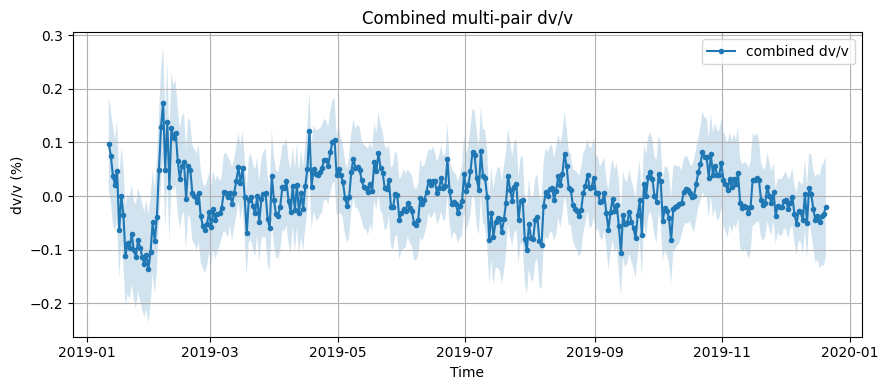

In [23]:
# -------------------------
# 2. combine all pairwise dv/v curves
# -------------------------
all_times = sorted({
    t
    for result in pair_results.values()
    for t in result["time"]
})

combined_dvv = []
combined_err = []
npairs_used = []

for t in all_times:
    dvv_vals = []
    err_vals = []

    for key, result in pair_results.items():
        times = result["time"]
        dvv = result["dvv_mean"]
        err = result["err_mean"]

        for i, tt in enumerate(times):
            if tt == t:
                if np.isfinite(dvv[i]) and np.isfinite(err[i]) and err[i] > 0:
                    dvv_vals.append(dvv[i])
                    err_vals.append(err[i])
                break

    dvv_vals = np.asarray(dvv_vals, dtype=float)
    err_vals = np.asarray(err_vals, dtype=float)

    # require at least one or two pairs here
    if len(dvv_vals) < 1:
        combined_dvv.append(np.nan)
        combined_err.append(np.nan)
        npairs_used.append(0)
        continue

    # inverse-variance weighting
    w = 1.0 / (err_vals ** 2)
    dvv_avg = np.sum(w * dvv_vals) / np.sum(w)
    err_avg = np.sqrt(1.0 / np.sum(w))

    combined_dvv.append(dvv_avg)
    combined_err.append(err_avg)
    npairs_used.append(len(dvv_vals))

network_result = {
    "time": all_times,
    "dvv_mean": np.asarray(combined_dvv),
    "err_mean": np.asarray(combined_err),
    "npairs_used": np.asarray(npairs_used),
}

# -------------------------
# 3. plot the combined dv/v
# -------------------------
plt.figure(figsize=(9, 4))
plt.plot(network_result["time"], network_result["dvv_mean"], ".-", label="combined dv/v")
plt.fill_between(
    network_result["time"],
    network_result["dvv_mean"] - network_result["err_mean"],
    network_result["dvv_mean"] + network_result["err_mean"],
    alpha=0.2,
)
plt.xlabel("Time")
plt.ylabel("dv/v (%)")
plt.title("Combined multi-pair dv/v")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
#########save############
import os
import pandas as pd



df = pd.DataFrame({
    "time": [str(t) for t in network_result["time"]],
    "dvv_mean": network_result["dvv_mean"],
    "err_mean": network_result["err_mean"],
    "npairs_used": network_result["npairs_used"],
})

df.to_csv(out_csv, index=False)

print("saved to:", out_csv)
print("exists?", os.path.exists(out_csv))
print("size:", os.path.getsize(out_csv) if os.path.exists(out_csv) else "missing")

saved to: /gpfs/fs2/scratch/tzhang57/noi/network_dvv.csv
exists? True
size: 23715
